<a href="https://colab.research.google.com/github/hj090/DACON_predict_14class/blob/dev_ysy/stage1_stage2__07_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

stage1+stage2+추론(07_12).ipynb의 사본

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1zcX8cA5s9V483yhTLouY-zjCrxUz8vXH

In [1]:
# 셀 A — numpy부터 먼저 정확히 고정 (이게 젤 먼저)
!pip install -q "numpy==1.26.4"

In [2]:
# 셀 B — 나머지
!pip install -q "scipy==1.15.3" "threadpoolctl==3.6.0" "joblib==1.5.3" "scikit-learn==1.8.0"
!pip install -q "transformers==4.46.3"
!pip uninstall -y torchvision -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timm 1.0.27 requires torchvision, which is not installed.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [3]:
# 셀 C — ONNX 관련 (원래 #0)
!pip install onnxmltools skl2onnx onnxruntime onnxconverter-common --break-system-packages -q
!pip install onnxmltools skl2onnx onnxruntime onnxconverter-common onnxscript --break-system-packages -q

In [4]:
!pip install --upgrade transformers sentence-transformers --break-system-packages -q

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 455, in run
    installed = install_given_reqs(
                ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/req/__init__.py", line 70, in install_given_reqs
    requirement.install(
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/req/req_install.py", line 851, in install
    install_wheel(
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/install/wheel.py", line 726, in install_wheel
    _install_wheel(
  File 

# Stage1

In [79]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##1. 라이브러리 불러오기

In [ ]:
import csv
import json
import os

In [7]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb
import numpy as np
import re
import pandas as pd

In [8]:
# 예측 대상 14개 클래스 (Macro-F1 계산에 사용)
ALL_CLASSES = [
    "read_file", "grep_search", "list_directory", "glob_pattern",
    "edit_file", "write_file", "apply_patch",
    "run_bash", "run_tests", "lint_or_typecheck",
    "ask_user", "plan_task", "web_search", "respond_only",
]

##2. 데이터 불러오기

In [9]:
DATA_DIR = "/content/drive/MyDrive/nlp_competition/data" ### 임유미 수정

In [10]:
# train.jsonl: 한 줄 = 샘플 하나
samples = [json.loads(line)
           for line in open(os.path.join(DATA_DIR, "train.jsonl"), encoding="utf-8")
           if line.strip()]

In [11]:
# train_labels.csv: id -> action 매핑
labels = {row["id"]: row["action"]
          for row in csv.DictReader(open(os.path.join(DATA_DIR, "train_labels.csv"), encoding="utf-8"))}

In [12]:
# 입력 X = current_prompt, 정답 y = action
X = [s["current_prompt"] for s in samples]
y = [labels[s["id"]] for s in samples]
ids = [s["id"] for s in samples]

In [13]:
# id로 원본 샘플(session_meta 포함)을 바로 찾기 위한 딕셔너리
samples_by_id = {s["id"]: s for s in samples}

In [14]:
print("samples:", len(X), "| classes:", len(set(y)))

samples: 70000 | classes: 14


##3. 학습 / 검증 데이터 분할

In [15]:
X_train, X_val, y_train, y_val, train_ids, val_ids = train_test_split(
    X, y, ids, test_size=0.2, stratify=y, random_state=42,
)
print("train:", len(X_train), "| val:", len(X_val))

train: 56000 | val: 14000


In [16]:
# session meta 추가 연결
from sklearn.compose import ColumnTransformer

In [17]:
def extract_session_features(sample):
  s = samples_by_id[sample]

  meta = s.get("session_meta", {}) or {}
  ws = meta.get("workspace", {}) or {}
  lang_mix = ws.get("language_mix") or {}
  dom_lang, dom_ratio = max(lang_mix.items(), key=lambda kv: kv[1]) if lang_mix else ("none", 0.0)

  return {
    "language_pref": meta.get("language_pref", "unknown"),
    "last_ci_status": ws.get("last_ci_status", "none"),
    "git_dirty": str(ws.get("git_dirty", False)),
    "user_tier": meta.get("user_tier", "unknown"),
    "turn_index": meta.get("turn_index", 0),
    "budget_tokens_remaining_log": np.log1p(meta.get("budget_tokens_remaining", 0)),
    "loc_log": np.log1p(ws.get("loc", 0)),
    "n_open_files": len(ws.get("open_files") or []),
    "dominant_code_lang": dom_lang,
    "dominant_code_ratio": dom_ratio,
    "n_code_langs": len(lang_mix),
    "elapsed_session_sec_log": np.log1p(meta.get("elapsed_session_sec", 0)),
}

In [18]:
# train_ids / val_ids 순서 그대로 매핑
session_train_df = pd.DataFrame([extract_session_features(i) for i in train_ids])
session_val_df = pd.DataFrame([extract_session_features(i) for i in val_ids])

In [19]:
def extract_history_features(sample_id):
    s = samples_by_id[sample_id]
    history = s.get("history", []) or []

    # 최근 assistant_action 찾기 (뒤에서부터 탐색)
    last_action = None
    turns_since = 0
    for turn in reversed(history):
        if turn.get("role") == "assistant_action":
            last_action = turn
            break
        turns_since += 1   # user 턴을 지나칠 때마다 카운트

    if last_action is None:
        # 아직 action이 한 번도 없었던 경우 (대화 시작 단계)
        return {
            "last_action_name": "none",
            "last_action_result_status": "none",
            "n_actions_so_far": 0,
            "last_action_ext": "none",
            "turns_since_last_action": len(history),
        }

    # 결과 요약에서 성공/실패/에러 신호 추출
    result_summary = (last_action.get("result_summary") or "").lower()
    if re.search(r"fail|error|exception|traceback", result_summary):
        result_status = "fail"
    elif re.search(r"\bok\b|success|passed", result_summary):
        result_status = "ok"
    else:
        result_status = "unknown"

    # 파일 확장자 추출 (args.path가 있을 경우)
    path = (last_action.get("args") or {}).get("path", "")
    ext_match = re.search(r"\.(\w+)$", path)
    ext = ext_match.group(1) if ext_match else "none"

    # 전체 action 개수 카운트
    n_actions = sum(1 for turn in history if turn.get("role") == "assistant_action")

    return {
        "last_action_name": last_action.get("name", "none"),
        "last_action_result_status": result_status,
        "n_actions_so_far": n_actions,
        "last_action_ext": ext,
        "turns_since_last_action": turns_since,
    }

history_train_df = pd.DataFrame([extract_history_features(i) for i in train_ids])
history_val_df = pd.DataFrame([extract_history_features(i) for i in val_ids])

In [20]:
# 원-핫 인코딩 (학습 데이터로 fit, 검증은 transform만)
CATEGORICAL_COLS = ["language_pref", "last_ci_status", "git_dirty", "user_tier", "dominant_code_lang",
                    "last_action_name", "last_action_result_status", "last_action_ext"]
NUMERIC_COLS = ["turn_index", "budget_tokens_remaining_log", "loc_log", "n_open_files", "dominant_code_ratio", "n_code_langs", "elapsed_session_sec_log",
                "n_actions_so_far", "turns_since_last_action"]

# session_train_df와 history_train_df 합치기
combined_train_df = pd.concat([session_train_df, history_train_df], axis=1)
combined_val_df = pd.concat([session_val_df, history_val_df], axis=1)

combined_encoder = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), CATEGORICAL_COLS),
    ("num", StandardScaler(), NUMERIC_COLS),   # 숫자는 변환 없이 그대로 통과
])

combined_train_enc = combined_encoder.fit_transform(combined_train_df)
combined_val_enc = combined_encoder.transform(combined_val_df)

##4. 모델 정의와 학습 (TF-IDF + LightGBM)

In [21]:
#규칙 기반 피처 클래스
class RuleFeatureExtractor(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self   # 학습할 게 없으니 그냥 자기 자신 반환

    def transform(self, X):
        return np.array([self._extract(text) for text in X])

    def _extract(self, text):
        return [
            1 if re.search(r'\b(read|열어|읽어)\b', text, re.I) else 0,
            1 if re.search(r'(grep|검색|찾아).*(코드|텍스트|패턴)', text, re.I) else 0,
            1 if re.search(r'(폴더|디렉토리|directory).*(뭐|목록|구조)', text, re.I) else 0,
            1 if re.search(r'\*\.\w+|글롭|glob|확장자', text, re.I) else 0,
            1 if re.search(r'(수정|고쳐|바꿔|edit)', text, re.I) else 0,
            1 if re.search(r'(새로|생성|만들어|write).*(파일|코드)', text, re.I) else 0,
            1 if re.search(r'(diff|patch|패치|변경사항)', text, re.I) else 0,
            1 if re.search(r'(셸|shell|bash|명령어|터미널)', text, re.I) else 0,
            1 if re.search(r'(테스트|test).*(실행|돌려|run)', text, re.I) else 0,
            1 if re.search(r'(린트|lint|타입체크|맞춤법)', text, re.I) else 0,
            1 if '?' in text else 0,
            1 if re.search(r'(계획|설계|plan)', text, re.I) else 0,
            1 if re.search(r'(웹|인터넷|구글|web)', text, re.I) else 0,
            1 if re.search(r'[\w\-]+\.[A-Za-z0-9]{1,6}\b|[\w\-]+/[\w\-./]+', text) else 0,  # 임유미 추가: 명시적 파일 경로/확장자 언급 여부
            len(text),
            len(re.findall(r'[a-zA-Z]', text)),
        ]

rule_extractor = RuleFeatureExtractor()
rule_features_train = rule_extractor.transform(X_train)
rule_features_val = rule_extractor.transform(X_val)

In [22]:
#LightGBM의 성능평가지표를 Macro-F1 직접 만들기

In [23]:
def macro_f1_eval(y_true, y_pred_proba):
    y_pred = y_pred_proba.reshape(len(y_true), -1).argmax(axis=1)
    f1 = f1_score(y_true, y_pred, average="macro")
    return "macro_f1", f1, True   # True = "높을수록 좋음"

In [24]:
#1. TF-IDF
tfidf_chi2 = Pipeline([
    #1-1) TF-IDF
    ("tfidf", TfidfVectorizer(ngram_range=(1,3), min_df=2, max_features=80_000,
                                sublinear_tf=True, lowercase=True)),
    #1-2) chi2 피처 선택
    ("chi2", SelectKBest(chi2, k=30_000)),
])

# 가지2: 규칙 기반 피처
rule = RuleFeatureExtractor()

# 두 갈래를 FeatureUnion으로 결합
vectorizer_pipe = FeatureUnion([
    ("tfidf_chi2", tfidf_chi2),
    ("rule_features", rule),
])

vectorizer = vectorizer_pipe
X_train_vec = vectorizer.fit_transform(X_train, y_train)
X_val_vec = vectorizer.transform(X_val)

#session meta, history 피쳐 결합
X_train_final = hstack([X_train_vec, combined_train_enc])
X_val_final = hstack([X_val_vec, combined_val_enc])

In [25]:
#2. LightGBM
clf = lgb.LGBMClassifier(n_estimators=400, num_leaves=100, min_child_samples=10, learning_rate=0.05,
                            objective="multiclass", class_weight="balanced", force_row_wise=True, random_state=42)
best_clf = clf

best_clf.fit(
    X_train_final, y_train,
    eval_set=[(X_val_final, y_val)],
    eval_metric=macro_f1_eval,
    callbacks=[lgb.early_stopping(stopping_rounds=150)],
)

[LightGBM] [Info] Total Bins 213235
[LightGBM] [Info] Number of data points in the train set: 56000, number of used features: 10525
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don'

,boosting_type,'gbdt'
,num_leaves,100
,max_depth,-1
,learning_rate,0.05
,n_estimators,400
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,10


In [26]:
tfidf_probs_train = best_clf.predict_proba(X_train_final)   # 학습셋 확률 (가중치 튜닝용)
tfidf_probs_val = best_clf.predict_proba(X_val_final)       # 검증셋 확률

rule_only_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
rule_only_clf.fit(rule_features_train, y_train)
rule_probs_train = rule_only_clf.predict_proba(rule_features_train)
rule_probs_val = rule_only_clf.predict_proba(rule_features_val)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [27]:
best_w = 1.0
best_threshold = 0.9

def route_by_confidence(ids, tfidf_probs, rule_probs, classes, w=best_w, threshold=best_threshold): ### 임유미 수정 (인자로 classes를 받도록 함수 정의부 수정)
    """
    Stage1 앙상블 예측 확률을 보고, 확신도에 따라 라우팅하는 함수

    Parameters
    ----------
    ids : list
        각 샘플의 고유 id
    tfidf_probs : np.ndarray (샘플수, 14)
        TF-IDF+LightGBM 모델의 확률
    rule_probs : np.ndarray (샘플수, 14)
        규칙피처+LogReg 모델의 확률
    classes: probs의 각 컬럼이 어떤 클래스를 의미하는지 알려주는 배열
        (반드시 predict_proba를 만든 모델의 .classes_ 를 그대로 넘길 것) ### 임유미 추가
    w : float
        TF-IDF 쪽 가중치
    threshold : float
        이 값 이상이면 Stage1에서 바로 확정

    Returns
    -------
    stage1_results : dict {id: action}
        확신도 높아서 Stage1에서 바로 결정된 것들
    stage2_input_ids : list
        확신도 낮아서 Stage2로 넘겨야 하는 id 목록
    stage2_probs : np.ndarray
        Stage2로 넘어가는 샘플들의 Stage1 확률 분포 (best_clf.predict_proba(X_vec) 결과)
    """
    ensemble_probs = w * tfidf_probs + (1 - w) * rule_probs
    max_conf = ensemble_probs.max(axis=1)      # 각 샘플의 "가장 높은 확률"
    pred_idx = ensemble_probs.argmax(axis=1)   # 그 확률에 해당하는 클래스 인덱스

    stage1_results = {}
    stage2_input_ids = []
    stage2_probs_list = []

    for sample_id, conf, idx, prob_row in zip(ids, max_conf, pred_idx, ensemble_probs):
        if conf >= threshold:
            #확신도 높음 → 확정
            stage1_results[sample_id] = classes[idx]   ### 임유미: ALL_CLASSES → classes로 변경
        else:
            #확신도 낮음 → Stage2로
            stage2_input_ids.append(sample_id)
            stage2_probs_list.append(prob_row)

    stage2_probs = np.array(stage2_probs_list) if stage2_probs_list else np.empty((0, len(ALL_CLASSES)))

    return stage1_results, stage2_input_ids, stage2_probs


In [28]:
#stage2 들어갈 데이터 받는 예시 코드
stage1_results, stage2_input_ids, stage2_probs = route_by_confidence(
    ids=val_ids,
    tfidf_probs=tfidf_probs_val,
    rule_probs=rule_probs_val,
    classes=best_clf.classes_,   ### 임유미 추가
)

print(f"Stage1에서 확정된 샘플 수: {len(stage1_results)}")
print(f"Stage2로 넘어가는 샘플 수: {len(stage2_input_ids)}")

Stage1에서 확정된 샘플 수: 2990
Stage2로 넘어가는 샘플 수: 11010


In [29]:
# 확정된 샘플들(Stage1에서 끝난 것들)만 따로 정확도 확인
ensemble_probs_val = best_w * tfidf_probs_val + (1-best_w) * rule_probs_val
max_conf = ensemble_probs_val.max(axis=1)
pred_idx = ensemble_probs_val.argmax(axis=1)
pred_labels = np.array([best_clf.classes_[i] for i in pred_idx])

confirmed_mask = max_conf >= best_threshold

confirmed_acc = (pred_labels[confirmed_mask] == np.array(y_val)[confirmed_mask]).mean()
print(f"✅ 확정 샘플 수: {confirmed_mask.sum()}")
print(f"🎯 확정 샘플 중 정확도: {confirmed_acc:.4f}")

✅ 확정 샘플 수: 2990
🎯 확정 샘플 중 정확도: 0.9559


##5. Stage1 검증 (Macro-F1)

In [30]:
ensemble_pred = np.array([best_clf.classes_[i] for i in ensemble_probs_val.argmax(axis=1)])
macro_f1 = f1_score(y_val, ensemble_pred, labels=ALL_CLASSES, average="macro", zero_division=0)
print(f"Validation Macro-F1: {macro_f1:.4f}")

Validation Macro-F1: 0.5823


# Stage2

##1. 라이브러리 정의

In [31]:
!pip uninstall -y torchcodec -q

In [32]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression

## 2. Stage2 데이터셋 구성

In [33]:
def build_stage2_input_text(sample, history_turns=3):
    history = sample.get("history", []) or []
    hist_text = "\n".join(str(turn) for turn in history[-history_turns:])
    return f"{hist_text}\n{sample.get('current_prompt', '')}".strip()

In [34]:
def build_stage2_dataset(stage2_ids, stage2_probs, samples_by_id, labels, session_encoder, history_turns=3):
    """
    stage2_ids/stage2_probs: route_by_confidence가 넘긴 것 그대로 (stage2_probs는 앙상블 확률)
    session_encoder: Stage1에서 이미 fit된 ColumnTransformer (train 기준) — transform만 함
    """
    texts, y_stage2 = [], []
    for sid in stage2_ids:
        s = samples_by_id[sid]
        texts.append(build_stage2_input_text(s, history_turns))
        y_stage2.append(labels[sid])

    # ---- session_meta 인코딩 (Stage1의 extract_session_features 재사용) ----
    session_df = pd.DataFrame([extract_session_features(sid) for sid in stage2_ids])
    history_df = pd.DataFrame([extract_history_features(sid) for sid in stage2_ids])   ### 윤서영 추가
    combined_df = pd.concat(   ### 윤서영 추가
        [session_df.reset_index(drop=True), history_df.reset_index(drop=True)], axis=1
    )
    session_enc = session_encoder.transform(combined_df)   ### 윤서영 수정
    if hasattr(session_enc, "toarray"):   # ColumnTransformer 결과가 sparse일 수 있음
        session_enc = session_enc.toarray()

    return texts, y_stage2, np.array(stage2_probs), session_enc.astype(np.float32)

In [35]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

In [36]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

In [37]:
embedder = SentenceTransformer("/content/drive/MyDrive/nlp_competition/model/minilm_local")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

## 3. history_turns 튜닝

history_turns 후보별로 데이터셋을 다시 만들고, 기본 C(=1.0)의 LogisticRegression으로
OOF Macro-F1을 비교해서 가장 좋은 history_turns를 고른다.
(MiniLM 인코딩을 후보 수만큼 반복하므로 후보가 많을수록 시간이 늘어남 — 필요시 후보 축소)

In [38]:
HISTORY_TURNS_CANDIDATES = [1, 2, 3,4,5]

In [39]:
best_ht, best_ht_f1, best_bundle = None, -1.0, None

In [40]:
for ht in HISTORY_TURNS_CANDIDATES:
    X_text_ht, y_ht, probs_ht, sess_ht = build_stage2_dataset(
        stage2_input_ids, stage2_probs, samples_by_id, labels, combined_encoder,
        history_turns=ht,
    )
    emb_ht = embedder.encode(X_text_ht, show_progress_bar=False)
    feat_ht = np.hstack([emb_ht, probs_ht, sess_ht])
    y_arr_ht = np.array(y_ht)

    oof_ht = np.empty(len(y_arr_ht), dtype=object)
    for train_idx, val_idx in skf.split(feat_ht, y_arr_ht):
        clf_ht = LogisticRegression(max_iter=1000, class_weight="balanced")
        clf_ht.fit(feat_ht[train_idx], y_arr_ht[train_idx])
        oof_ht[val_idx] = clf_ht.predict(feat_ht[val_idx])

    f1_ht = f1_score(y_arr_ht, oof_ht, labels=ALL_CLASSES, average="macro", zero_division=0)
    print(f"[history_turns={ht}] Macro-F1 (OOF, C=default): {f1_ht:.4f}")

    if f1_ht > best_ht_f1:
        best_ht_f1 = f1_ht
        best_ht = ht
        best_bundle = (X_text_ht, y_ht, probs_ht, sess_ht, emb_ht, feat_ht)

print(f"\n선택된 history_turns = {best_ht} (Macro-F1={best_ht_f1:.4f})")


[history_turns=1] Macro-F1 (OOF, C=default): 0.4447
[history_turns=2] Macro-F1 (OOF, C=default): 0.4360
[history_turns=3] Macro-F1 (OOF, C=default): 0.4887
[history_turns=4] Macro-F1 (OOF, C=default): 0.4873
[history_turns=5] Macro-F1 (OOF, C=default): 0.4572

선택된 history_turns = 3 (Macro-F1=0.4887)


In [41]:
# 이후 코드는 최적 history_turns로 만든 데이터셋을 그대로 사용
X_stage2_text, y_stage2, stage1_probs_stage2, session_stage2_enc, emb_all, feat_all = best_bundle
y_stage2_arr = np.array(y_stage2)

print(f"Stage2 학습 후보: {len(X_stage2_text)}건")
print(f"session_meta 인코딩 shape: {session_stage2_enc.shape}")
print(pd.Series(y_stage2).value_counts())
print("session_stage2_enc shape:", session_stage2_enc.shape)
print(combined_encoder.get_feature_names_out())  # 'num__elapsed_session_sec_log' 포함 확인

Stage2 학습 후보: 11010건
session_meta 인코딩 shape: (11010, 75)
grep_search          1976
read_file            1849
edit_file            1413
glob_pattern         1057
list_directory        866
run_tests             798
run_bash              774
apply_patch           649
ask_user              489
plan_task             467
lint_or_typecheck     404
web_search            241
write_file             21
respond_only            6
Name: count, dtype: int64
session_stage2_enc shape: (11010, 75)
['cat__language_pref_en' 'cat__language_pref_ko'
 'cat__language_pref_mixed' 'cat__last_ci_status_failed'
 'cat__last_ci_status_none' 'cat__last_ci_status_passed'
 'cat__git_dirty_False' 'cat__git_dirty_True' 'cat__user_tier_enterprise'
 'cat__user_tier_free' 'cat__user_tier_pro' 'cat__dominant_code_lang_go'
 'cat__dominant_code_lang_java' 'cat__dominant_code_lang_py'
 'cat__dominant_code_lang_rs' 'cat__dominant_code_lang_ts'
 'cat__dominant_code_lang_tsx' 'cat__dominant_code_lang_vue'
 'cat__dominant_code_lan

## 3-1. Stage2에 어휘 규칙 피처(rule_features) + 경로 언급 피처 추가

In [42]:

"""## 3-1. Stage2에 어휘 규칙 피처(rule_features) + 경로 언급 피처 추가

read_file / grep_search / list_directory / glob_pattern 4개 클래스가 서로 혼동되는 문제 분석 결과,
"열어/보여줘 + 명시적 파일명" 같은 어휘 신호를 Stage2가 전혀 못 쓰고 있는 게 확인됨.
Stage1에서 이미 쓰던 RuleFeatureExtractor(정규식 15개 + 신규 경로/확장자 언급 피처 1개, 총 16개)를
Stage2 텍스트(X_stage2_text)에도 적용해서 feat_all에 추가한다.
rule_features는 이진 플래그 위주지만 len(text), 영문자 수처럼 스케일이 다른 값도 섞여 있어
LogisticRegression에 넣기 전에 StandardScaler로 스케일링한다.
"""

from sklearn.preprocessing import StandardScaler

rule_features_stage2 = rule_extractor.transform(X_stage2_text)  # (n_samples, 16)

stage2_rule_scaler = StandardScaler()
rule_features_stage2_scaled = stage2_rule_scaler.fit_transform(rule_features_stage2)

In [43]:
"""## 3-1. Stage2에 어휘 규칙 피처(rule_features) 추가 — current_prompt 기준

history+prompt 전체 텍스트에 rule_features를 적용하면 과거 턴의 키워드가 섞여
신호가 흐려짐(-0.0059 확인됨). current_prompt에만 적용한 버전이 가장 좋았으므로(+0.0056)
이걸 최종 채택.
"""

current_prompt_texts = [samples_by_id[sid].get("current_prompt", "") for sid in stage2_input_ids]
rule_features_stage2 = rule_extractor.transform(current_prompt_texts)

stage2_rule_scaler = StandardScaler()
rule_features_stage2_scaled = stage2_rule_scaler.fit_transform(rule_features_stage2)

feat_all = np.hstack([emb_all, stage1_probs_stage2, session_stage2_enc, rule_features_stage2_scaled])
print("rule_features_stage2 shape:", rule_features_stage2.shape)
print("feat_all shape (rule_features 추가 후):", feat_all.shape)

rule_features_stage2 shape: (11010, 16)
feat_all shape (rule_features 추가 후): (11010, 489)


## 4. GridSearchCV로 C 튜닝

최적 history_turns로 고정한 feat_all / y_stage2_arr 기준으로 C를 탐색한다.

선택된 C = 0.1874 (CV Macro-F1=0.4895)
         C  Macro-F1 (mean)  Macro-F1 (std)
  0.001000         0.251050        0.007479
  0.002848         0.328247        0.005707
  0.008111         0.399013        0.005968
  0.023101         0.451210        0.005530
  0.065793         0.473090        0.006784
  0.187382         0.489453        0.009716
  0.533670         0.485615        0.013942
  1.519911         0.479371        0.012105
  4.328761         0.474112        0.015942
 12.328467         0.462532        0.017592
 35.111917         0.445043        0.013995
100.000000         0.441345        0.027468


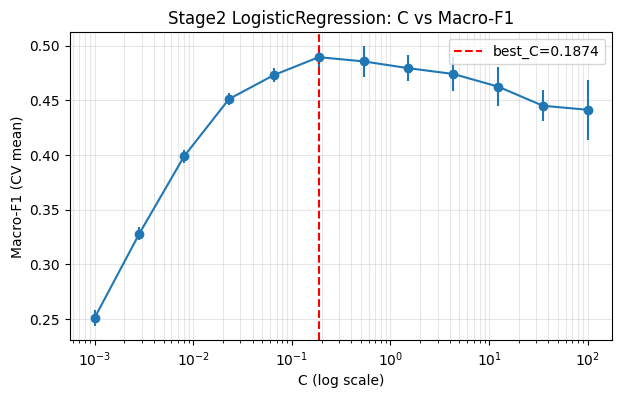

In [44]:
import numpy as np
import pandas as pd

param_grid = {
    "C": np.logspace(-3, 2, 12),   # 0.001 ~ 100, 로그스케일 12개 지점
}
gs = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight="balanced"),
    param_grid,
    scoring="f1_macro",
    cv=skf,
    n_jobs=-1,
)
gs.fit(feat_all, y_stage2_arr)

best_C = gs.best_params_["C"]
print(f"선택된 C = {best_C:.4g} (CV Macro-F1={gs.best_score_:.4f})")

# ---- C별 Macro-F1 표로 확인 ----
cv_results = pd.DataFrame(gs.cv_results_)
c_scores = cv_results[["param_C", "mean_test_score", "std_test_score"]].copy()
c_scores.columns = ["C", "Macro-F1 (mean)", "Macro-F1 (std)"]
c_scores = c_scores.sort_values("C").reset_index(drop=True)
print(c_scores.to_string(index=False))

# ---- 그래프로도 확인 ----
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.errorbar(c_scores["C"], c_scores["Macro-F1 (mean)"], yerr=c_scores["Macro-F1 (std)"], marker="o")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Macro-F1 (CV mean)")
plt.title("Stage2 LogisticRegression: C vs Macro-F1")
plt.axvline(best_C, color="red", linestyle="--", label=f"best_C={best_C:.4g}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

##5. 분류 헤드 (Fold 앙상블: soft-voting으로 OOF 예측 생성)

기존에는 fold별로 학습한 head_fold를 predict()만 하고 버렸는데,
여기서는 fold별 확률(predict_proba)을 저장해서 평균(soft voting)한 뒤 argmax로 예측한다.
fold_models 리스트는 저장 용량이 커지므로(head 5개), 기본적으로는 OOF 평가에만 사용하고
실제 배포용 모델은 아래에서 전체 데이터로 재학습한 head_final 하나만 저장한다.

In [45]:
fold_models = []
oof_proba = np.zeros((len(y_stage2_arr), len(ALL_CLASSES)))

In [46]:
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(feat_all, y_stage2_arr)):
    head_fold = LogisticRegression(max_iter=1000, class_weight="balanced", C=best_C)
    head_fold.fit(feat_all[train_idx], y_stage2_arr[train_idx])

    proba = head_fold.predict_proba(feat_all[val_idx])
    for j, c in enumerate(head_fold.classes_):
        col = ALL_CLASSES.index(c)
        oof_proba[val_idx, col] = proba[:, j]

    fold_models.append(head_fold)
    print(f"Fold {fold_idx+1}/{n_splits} 완료")

oof_preds = np.array(ALL_CLASSES)[oof_proba.argmax(axis=1)]
stage2_oof_dict = dict(zip(stage2_input_ids, oof_preds))

Fold 1/5 완료
Fold 2/5 완료
Fold 3/5 완료
Fold 4/5 완료
Fold 5/5 완료


In [47]:
# ---- 전체 stage2 데이터로 최종 head 학습 (best_C 반영, 배포용) ----
head_final = LogisticRegression(max_iter=1000, class_weight="balanced", C=best_C)
head_final.fit(feat_all, y_stage2_arr)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1873817422860383
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of prob

In [48]:
# (선택) fold 앙상블을 실제 추론에도 쓰고 싶다면 아래처럼 fold_models 5개를 저장해서
# 추론 시 predict_proba 평균을 내면 된다. 다만 저장 용량이 head_final 하나 대비 5배가 되므로
# 1GB 용량 제약을 먼저 확인할 것.
# joblib.dump(fold_models, "./model/stage2_head_folds.pkl", compress=3)

실험중

In [49]:
def extract_open_files_features(sample_id):
    s = samples_by_id[sample_id]
    ws = s.get("session_meta", {}).get("workspace", {}) or {}
    open_files = ws.get("open_files") or []

    # 열린 파일들의 확장자 분포
    exts = [re.search(r'\.(\w+)$', f).group(1) for f in open_files if re.search(r'\.(\w+)$', f)]
    dominant_ext = max(set(exts), key=exts.count) if exts else "none"

    # current_prompt가 언급하는 파일이 open_files 안에 있는지 (매우 강한 신호일 수 있음!)
    return {
        "open_files_dominant_ext": dominant_ext,
        "open_files_ext_diversity": len(set(exts)),
    }

In [50]:
def extract_action_sequence_features(sample_id):
    s = samples_by_id[sample_id]
    history = s.get("history", []) or []
    actions = [t.get("name") for t in history if t.get("role") == "assistant_action"]

    last2 = "->".join(actions[-2:]) if len(actions) >= 2 else (actions[-1] if actions else "none")
    return {"last2_action_seq": last2}

In [53]:
open_files_df = pd.DataFrame([extract_open_files_features(sid) for sid in stage2_input_ids])
seq_df = pd.DataFrame([extract_action_sequence_features(sid) for sid in stage2_input_ids])

new_cat_df = pd.concat([
    open_files_df[["open_files_dominant_ext"]],
    seq_df[["last2_action_seq"]],
], axis=1)

new_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
new_encoded = new_encoder.fit_transform(new_cat_df)

In [54]:
skf_test = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)
base_feat = feat_all
single_feat = np.hstack([base_feat, new_encoded])

oof_new = np.empty(len(y_stage2_arr), dtype=object)
oof_base = np.empty(len(y_stage2_arr), dtype=object)

for tr, va in skf_test.split(single_feat, y_stage2_arr):
    # 1) 새 feature 포함 모델
    clf_new = LogisticRegression(max_iter=2000, class_weight="balanced", C=best_C)
    clf_new.fit(single_feat[tr], y_stage2_arr[tr])
    oof_new[va] = clf_new.predict(single_feat[va])

    # 2) 기준선 모델 (base_feat만 사용) ← 이 부분이 빠져 있었음
    clf_base = LogisticRegression(max_iter=2000, class_weight="balanced", C=best_C)
    clf_base.fit(base_feat[tr], y_stage2_arr[tr])
    oof_base[va] = clf_base.predict(base_feat[va])

f1_base = f1_score(y_stage2_arr, oof_base, labels=ALL_CLASSES, average="macro", zero_division=0)
f1_new = f1_score(y_stage2_arr, oof_new, labels=ALL_CLASSES, average="macro", zero_division=0)
print(f"기준선: {f1_base:.4f}")
print(f"open_files+action_seq 추가: {f1_new:.4f} (차이: {f1_new-f1_base:+.4f})")

기준선: 0.4924
open_files+action_seq 추가: 0.4984 (차이: +0.0061)


In [59]:
# ── 1) feat_all을 이 조합으로 "공식" 확정 ──────────────────────────
feat_all = single_feat   # emb_all + probs + session + rule + new_encoded (open_files+action_seq)
print("✅ 확정된 feat_all shape:", feat_all.shape)

# ── 2) 전역 skf도 이제부터는 random_state=99로 통일 ──────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)   # ⭐ 앞으로 이걸 "공식 skf"로 사용

# ── 3) head_final을 이 feat_all로 "전체 데이터" 학습 (진짜 최종 모델) ──
head_final = LogisticRegression(max_iter=1000, class_weight="balanced", C=best_C)
head_final.fit(feat_all, y_stage2_arr)
print("✅ head_final 재학습 완료")

# ── 4) 공식 OOF도 이 skf + feat_all로 재계산 (보고서/분석용) ──────────
oof_proba = np.zeros((len(y_stage2_arr), len(ALL_CLASSES)))
for tr, va in skf.split(feat_all, y_stage2_arr):
    head_fold = LogisticRegression(max_iter=1000, class_weight="balanced", C=best_C)
    head_fold.fit(feat_all[tr], y_stage2_arr[tr])
    proba = head_fold.predict_proba(feat_all[va])
    for j, c in enumerate(head_fold.classes_):
        oof_proba[va, ALL_CLASSES.index(c)] = proba[:, j]

oof_preds = np.array(ALL_CLASSES)[oof_proba.argmax(axis=1)]
stage2_oof_dict = dict(zip(stage2_input_ids, oof_preds))

# ── 5) 최종 확인 ──────────────────────────────────────────────
stage2_macro_f1 = f1_score(y_stage2_arr, oof_preds, labels=ALL_CLASSES, average="macro", zero_division=0)
print(f"✅ 최종 확정된 Stage2 Macro-F1: {stage2_macro_f1:.4f}")

✅ 확정된 feat_all shape: (11010, 694)
✅ head_final 재학습 완료
✅ 최종 확정된 Stage2 Macro-F1: 0.4984


In [67]:
open_files_df = pd.DataFrame([extract_open_files_features(sid) for sid in stage2_input_ids])
seq_df = pd.DataFrame([extract_action_sequence_features(sid) for sid in stage2_input_ids])

new_cat_df = pd.concat([
    open_files_df[["open_files_dominant_ext"]],
    seq_df[["last2_action_seq"]],
], axis=1)

new_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
new_encoded = new_encoder.fit_transform(new_cat_df)
print("new_encoded shape:", new_encoded.shape)

# 2) feat_all 확정 (emb_all + probs + session + rule + new_encoded)
feat_all = np.hstack([
    emb_all, stage1_probs_stage2, session_stage2_enc,
    rule_features_stage2_scaled, new_encoded,
])
print("feat_all shape:", feat_all.shape)

# 3) skf를 "이 순간부로 공식 고정" — random_state=99로 통일
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)

# 4) OOF 계산 (공식 skf로)
oof_proba = np.zeros((len(y_stage2_arr), len(ALL_CLASSES)))
for tr, va in skf.split(feat_all, y_stage2_arr):
    head_fold = LogisticRegression(max_iter=1000, class_weight="balanced", C=best_C)
    head_fold.fit(feat_all[tr], y_stage2_arr[tr])
    proba = head_fold.predict_proba(feat_all[va])
    for j, c in enumerate(head_fold.classes_):
        oof_proba[va, ALL_CLASSES.index(c)] = proba[:, j]

oof_preds = np.array(ALL_CLASSES)[oof_proba.argmax(axis=1)]
stage2_oof_dict = dict(zip(stage2_input_ids, oof_preds))

# 5) 전체 데이터로 head_final 최종 학습 (실전 배포용)
head_final = LogisticRegression(max_iter=1000, class_weight="balanced", C=best_C)
head_final.fit(feat_all, y_stage2_arr)

# 6) 최종 확인
stage2_macro_f1 = f1_score(y_stage2_arr, oof_preds, labels=ALL_CLASSES, average="macro", zero_division=0)
print(f"\n✅ 최종 확정 Stage2 Macro-F1: {stage2_macro_f1:.4f}")



new_encoded shape: (11010, 205)
feat_all shape: (11010, 694)

✅ 최종 확정 Stage2 Macro-F1: 0.5570


## 6. (선택) 임베딩 모델 부분 파인튜닝

시간/자원 여유가 있을 때만 실행. DO_FINETUNE=True로 바꾸면 같은 클래스(action) 라벨을 가진
Stage2 텍스트끼리는 가깝게, 다른 클래스는 멀게 학습하는 대조학습(CosineSimilarityLoss)으로
MiniLM을 몇 epoch만 가볍게 파인튜닝한다. 결과가 좋을 때만 embedder를 교체해서 이어서 쓸 것
(용량/추론시간이 늘어나지 않는지 꼭 재확인 — 파인튜닝해도 아키텍처/파라미터 수는 동일하므로
1GB·10분 제약에는 영향 없음).

In [56]:
DO_FINETUNE = True  # 필요할 때 True로 변경

In [60]:
if DO_FINETUNE:
    import random
    from sentence_transformers import InputExample, losses
    from torch.utils.data import DataLoader

    random.seed(42)

    # 같은 클래스면 유사도 1, 다른 클래스면 0으로 학습 쌍 생성 (클래스당 과도한 조합 방지 위해 샘플링)
    by_class = {}
    for text, label in zip(X_stage2_text, y_stage2):
        by_class.setdefault(label, []).append(text)

    train_examples = []
    N_POS_PER_CLASS = 300
    N_NEG_PAIRS = 1500

    for label, texts in by_class.items():
        if len(texts) < 2:
            continue
        for _ in range(min(N_POS_PER_CLASS, len(texts) * 2)):
            a, b = random.sample(texts, 2)
            train_examples.append(InputExample(texts=[a, b], label=1.0))

    all_labels = list(by_class.keys())
    for _ in range(N_NEG_PAIRS):
        l1, l2 = random.sample(all_labels, 2)
        a = random.choice(by_class[l1])
        b = random.choice(by_class[l2])
        train_examples.append(InputExample(texts=[a, b], label=0.0))

    random.shuffle(train_examples)
    print(f"파인튜닝 학습 쌍: {len(train_examples)}개")

    train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=32)
    train_loss = losses.CosineSimilarityLoss(model=embedder)

    embedder.fit(
        train_objectives=[(train_dataloader, train_loss)],
        epochs=1,               # 과적합/시간 고려해 1~2 epoch 정도만
        warmup_steps=int(len(train_dataloader) * 0.1),
        show_progress_bar=True,
    )

    # 파인튜닝된 embedder로 임베딩 재계산 + head 재학습해서 개선 여부 확인
    emb_all_ft = embedder.encode(X_stage2_text, show_progress_bar=True)
    feat_all_ft = np.hstack([emb_all_ft, stage1_probs_stage2, session_stage2_enc])

    oof_preds_ft = np.empty(len(y_stage2_arr), dtype=object)
    for train_idx, val_idx in skf.split(feat_all_ft, y_stage2_arr):
        clf_ft = LogisticRegression(max_iter=1000, class_weight="balanced", C=best_C)
        clf_ft.fit(feat_all_ft[train_idx], y_stage2_arr[train_idx])
        oof_preds_ft[val_idx] = clf_ft.predict(feat_all_ft[val_idx])

    f1_ft = f1_score(y_stage2_arr, oof_preds_ft, labels=ALL_CLASSES, average="macro", zero_division=0)
    print(f"[파인튜닝 후] Stage2 Macro-F1 (OOF): {f1_ft:.4f}  (파인튜닝 전 기준과 비교해서 개선됐을 때만 채택)")

    # 개선됐을 경우에만 채택, 개선 안 됐을 경우 롤백 - 윤서영 수정
    if f1_ft > best_ht_f1:   # 실제로 나아졌을 때만 채택
      emb_all, feat_all = emb_all_ft, feat_all_ft
      head_final = LogisticRegression(max_iter=1000, class_weight="balanced", C=best_C).fit(feat_all, y_stage2_arr)
    else:
        embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")  # 원본으로 롤백!


파인튜닝 학습 쌍: 5154개


Step,Training Loss


Batches:   0%|          | 0/345 [00:00<?, ?it/s]

[파인튜닝 후] Stage2 Macro-F1 (OOF): 0.5284  (파인튜닝 전 기준과 비교해서 개선됐을 때만 채택)


#Stage2 임베더 오프라인 저장 (minilm_local 생성)

In [71]:
MINILM_SAVE_PATH = "/content/drive/MyDrive/nlp_competition_5/model/minilm_local"
os.makedirs(os.path.dirname(MINILM_SAVE_PATH), exist_ok=True)

In [72]:
# 셀 35에서 이미 로드/사용된 embedder를 그대로 저장 (재다운로드 X, 가중치 동일성 보장)
embedder.save(MINILM_SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [73]:
print("저장 완료:", MINILM_SAVE_PATH)
print("저장된 파일 목록:", os.listdir(MINILM_SAVE_PATH))

저장 완료: /content/drive/MyDrive/nlp_competition_5/model/minilm_local
저장된 파일 목록: ['tokenizer.json', '1_Pooling', 'config_sentence_transformers.json', 'config.json', 'model.safetensors', 'README.md', 'tokenizer_config.json', 'sentence_bert_config.json', 'modules.json', 'special_tokens_map.json']


##7. Stage2 Macro-F1 측정

In [74]:
stage2_macro_f1 = f1_score(y_stage2_arr, oof_preds, labels=ALL_CLASSES, average="macro", zero_division=0)
print(f"Stage2 단독 Validation Macro-F1 (OOF): {stage2_macro_f1:.4f}")
print(classification_report(y_stage2_arr, oof_preds, labels=ALL_CLASSES, zero_division=0))

Stage2 단독 Validation Macro-F1 (OOF): 0.5570
                   precision    recall  f1-score   support

        read_file       0.51      0.38      0.44      1849
      grep_search       0.60      0.50      0.54      1976
   list_directory       0.35      0.63      0.45       866
     glob_pattern       0.55      0.54      0.55      1057
        edit_file       0.80      0.72      0.76      1413
       write_file       0.22      0.38      0.28        21
      apply_patch       0.56      0.68      0.61       649
         run_bash       0.69      0.62      0.65       774
        run_tests       0.63      0.64      0.64       798
lint_or_typecheck       0.42      0.57      0.48       404
         ask_user       0.55      0.46      0.50       489
        plan_task       0.54      0.54      0.54       467
       web_search       0.45      0.64      0.53       241
     respond_only       0.83      0.83      0.83         6

         accuracy                           0.56     11010
        ma

## 혼동행렬 확인

In [75]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_stage2_arr, oof_preds, labels=ALL_CLASSES)
cm_df = pd.DataFrame(cm, index=ALL_CLASSES, columns=ALL_CLASSES)

target = ["read_file", "grep_search", "list_directory", "glob_pattern"]
print(cm_df.loc[target, target])
print()
# 이 4개 클래스가 서로한테 오답을 얼마나 주는지 vs 다른 클래스로 새는지 비교
print(cm_df.loc[target].sum(axis=1))       # 실제 개수
print(cm_df.loc[target, target].sum(axis=1))  # 이 4개 그룹 내에서 소비된 오답 수

mask = (np.array(y_stage2_arr) == "read_file") & (oof_preds == "list_directory")
confused_ids = np.array(stage2_input_ids)[mask]
for sid in confused_ids[:15]:
    print(sid, "→", build_stage2_input_text(samples_by_id[sid], history_turns=3)[-200:])

                read_file  grep_search  list_directory  glob_pattern
read_file             705          363             460           198
grep_search           361          982             321           176
list_directory        132           99             546            52
glob_pattern          136          126             167           575

read_file         1849
grep_search       1976
list_directory     866
glob_pattern      1057
dtype: int64
read_file         1726
grep_search       1840
list_directory     829
glob_pattern      1004
dtype: int64
sess_au_546812_005-step_03 → 듯. 인증 관련 파일들부터 추려줘'}
{'role': 'assistant_action', 'name': 'glob_pattern', 'args': {'pattern': 'src/**/*auth*.py'}, 'result_summary': "1 files matched 'src/**/*auth*.py'"}
auth.py 하나뿐이네. refresh 핸들러 보자
sess_au_932586_009-step_01 → ci 워크플로가 단계가 너무 중구난방이라 정리하고 싶어. 일단 ci.yml 내용 보여줘
sess_sim_20260522_008433-step_02 → '모델 쪽 테스트 깨진 거 없나 확인'}
{'role': 'assistant_action', 'name': 'run_bash', 'args': {'cmd': 'node script.

#Stage1+Stage2 전체 Macro-F1 측정

In [76]:
##5. Stage1 + Stage2 통합 Macro-F1 (전체 val_ids 커버)

final_preds = dict(stage1_results)          # stage1 확정분 1,643건
final_preds.update(stage2_oof_dict)         # stage2 전체 12,357건 (OOF 예측)

final_ids = list(final_preds.keys())
print(f"통합 샘플 수: {len(final_ids)}")    # 이제 14,000이 나와야 정상

y_true_final = [labels[i] for i in final_ids]
y_pred_final = [final_preds[i] for i in final_ids]

overall_macro_f1 = f1_score(y_true_final, y_pred_final, labels=ALL_CLASSES, average="macro", zero_division=0)
print(f"🎯 Stage1+Stage2 통합 Validation Macro-F1: {overall_macro_f1:.4f}")
print(classification_report(y_true_final, y_pred_final, labels=ALL_CLASSES, zero_division=0))

통합 샘플 수: 14000
🎯 Stage1+Stage2 통합 Validation Macro-F1: 0.6404
                   precision    recall  f1-score   support

        read_file       0.51      0.38      0.44      1851
      grep_search       0.60      0.50      0.55      1982
   list_directory       0.35      0.63      0.45       866
     glob_pattern       0.55      0.54      0.55      1057
        edit_file       0.87      0.82      0.84      2234
       write_file       0.91      0.95      0.93       296
      apply_patch       0.67      0.76      0.71       965
         run_bash       0.75      0.70      0.72      1014
        run_tests       0.65      0.66      0.66       912
lint_or_typecheck       0.45      0.59      0.51       457
         ask_user       0.57      0.48      0.52       540
        plan_task       0.57      0.57      0.57       536
       web_search       0.46      0.64      0.53       255
     respond_only       1.00      1.00      1.00      1035

         accuracy                           0.64   

#전체 데이터로 재학습 & 모델 저장

In [81]:
os.makedirs("./model", exist_ok=True)

joblib.dump(head_final, "./model/stage2_head.pkl", compress=3)
joblib.dump(new_encoder, "./model/stage2_new_encoder.pkl", compress=3)   # ⭐ 이것도 꼭 저장!

print("✅ head_final, new_encoder 저장 완료")
print("head_final이 학습한 피처 수:", head_final.n_features_in_)

✅ head_final, new_encoder 저장 완료
head_final이 학습한 피처 수: 694


In [83]:
import shutil

os.makedirs("/content/drive/MyDrive/nlp_competition_5/model", exist_ok=True)
shutil.copy("./model/stage2_head.pkl", "/content/drive/MyDrive/nlp_competition_5/model/stage2_head.pkl")
shutil.copy("./model/stage2_new_encoder.pkl", "/content/drive/MyDrive/nlp_competition_5/model/stage2_new_encoder.pkl")

'/content/drive/MyDrive/nlp_competition_5/model/stage2_new_encoder.pkl'

In [84]:
# 전체 학습 데이터로 재학습
vectorizer_final = vectorizer_pipe
X_full_vec = vectorizer_final.fit_transform(X, y)

# session_meta, history도 전체 데이터 기준으로 재학습 ---
session_full_df = pd.DataFrame([extract_session_features(i) for i in ids])
history_full_df = pd.DataFrame([extract_history_features(i) for i in ids])


# session + history 결합
combined_full_df = pd.concat(
    [session_full_df.reset_index(drop=True), history_full_df.reset_index(drop=True)],
    axis=1,
)

session_encoder_final = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), CATEGORICAL_COLS),
    ("num", StandardScaler(), NUMERIC_COLS),
])
session_full_enc = session_encoder_final.fit_transform(combined_full_df)

X_full_final = hstack([X_full_vec, session_full_enc])   # session_meta 포함!

clf_final = clf
clf_final.fit(X_full_final, y)

rule_features_full = rule_extractor.transform(X)
rule_only_clf_final = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
rule_only_clf_final.fit(rule_features_full, y)

[LightGBM] [Info] Total Bins 266748
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 13264
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not w

#stage1 경량화 - 윤서영 추가

In [85]:
from onnxmltools.convert import convert_lightgbm
from onnxmltools.convert.common.data_types import FloatTensorType

#LightGBM -> ONNX 변환
n_features = X_full_final.shape[1]   # 학습에 쓴 전체 피처 개수
initial_type = [('input', FloatTensorType([None, n_features]))]

onnx_model = convert_lightgbm(
    clf_final,
    initial_types=initial_type,
    target_opset=13,
    zipmap=False,   #확률 출력이 딕셔너리(ZipMap)가 아니라 배열로 나오게
)

In [86]:
# 저장 (추론용 script.py가 ./model/tfidf_lgbm.onnx 을 불러옵니다)
os.makedirs("./model", exist_ok=True)

joblib.dump(vectorizer_final, "./model/vectorizer.pkl", compress=3)
joblib.dump(session_encoder_final, "./model/session_encoder.pkl", compress=3)  # 임유미  추가
with open("./model/tfidf_lgbm.onnx", "wb") as f: #윤서영 수정
    f.write(onnx_model.SerializeToString())
joblib.dump(rule_only_clf_final, "./model/rule_logreg.pkl", compress=3)
joblib.dump(head_final, "./model/stage2_head.pkl", compress=3) # 임유미 추가
joblib.dump(stage2_rule_scaler, "./model/stage2_rule_scaler.pkl", compress=3) # 임유미 추가

print("저장 완료: ./model/tfidf_lgbm.onnx")

저장 완료: ./model/tfidf_lgbm.onnx


# Stage2 경량화(ONNX 변환 + 동적 양자화) - 임효주 추가

In [87]:
from sentence_transformers import SentenceTransformer

# 반드시 로컬 경로에서 로드 — 서버에서 쓰는 것과 동일 조건으로 비교하기 위함
MINILM_PATH = "/content/drive/MyDrive/nlp_competition_5/model/minilm_local"  # 방금 저장한 경로와 동일하게 # 실제 경로로 수정
embedder_for_export = SentenceTransformer(MINILM_PATH)

print(embedder_for_export)                              # Normalize 모듈 포함 여부 확인
max_seq_length = embedder_for_export.get_max_seq_length()
print("max_seq_length:", max_seq_length)

transformer_module = embedder_for_export[0]              # Transformer 서브모듈
auto_model = transformer_module.auto_model
tokenizer = transformer_module.tokenizer

sample_enc = tokenizer(["샘플 문장"], return_tensors="pt")
print("tokenizer 출력 키:", list(sample_enc.keys()))       # token_type_ids 포함 여부 확인

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
)
max_seq_length: 128
tokenizer 출력 키: ['input_ids', 'attention_mask']


ONNX 변환 (float32) — 2.2.1 전반부

In [88]:
import torch, os

class MeanPoolingWrapper(torch.nn.Module):
    def __init__(self, auto_model):
        super().__init__()
        self.auto_model = auto_model
    def forward(self, input_ids, attention_mask):
        out = self.auto_model(input_ids=input_ids, attention_mask=attention_mask)
        token_embeddings = out.last_hidden_state
        mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        summed = (token_embeddings * mask).sum(1)
        counts = mask.sum(1).clamp(min=1e-9)
        return summed / counts

wrapper = MeanPoolingWrapper(auto_model).eval().to("cpu")   # ← 이 줄 수정: .to("cpu") 추가

dummy = tokenizer(["예시 문장입니다"], return_tensors="pt",
                   padding="max_length", truncation=True, max_length=max_seq_length)
# dummy는 이미 CPU 텐서 (tokenizer 기본값) — wrapper도 CPU로 맞춰줬으니 이제 일치함

os.makedirs("./model", exist_ok=True)
torch.onnx.export(
    wrapper,
    (dummy["input_ids"], dummy["attention_mask"]),
    "./model/minilm_stage2.onnx",
    input_names=["input_ids", "attention_mask"],
    output_names=["sentence_embedding"],
    dynamic_axes={
        "input_ids": {0: "batch", 1: "seq"},
        "attention_mask": {0: "batch", 1: "seq"},
        "sentence_embedding": {0: "batch"},
    },
    opset_version=14,
)
print("Stage2 임베더 ONNX(float32) 변환 완료: ./model/minilm_stage2.onnx")

/tmp/ipykernel_2195/900089875.py:22: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0714 12:37:05.996000 2195 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0714 12:37:07.370000 2195 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0714 12:37:07.372000 2195 torch/onnx/_internal/exporter/_registration.py:110] torchvision

[torch.onnx] Obtain model graph for `MeanPoolingWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MeanPoolingWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /project/onnx/version_converter/adapters/no_previous_version.h:24: adapt: Assertion `false` fa

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/exporter/_onnx_program.py:487: UserWarning: # The axis name: seq will not be used, since it shares the same shape constraints with another axis: seq.
  rename_mapping = _dynamic_shapes.create_rename_mapping(


Stage2 임베더 ONNX(float32) 변환 완료: ./model/minilm_stage2.onnx


In [89]:
import os
print(os.path.exists("/content/drive/MyDrive/nlp_competition_5/model/minilm_local"))
print(os.listdir("/content/drive/MyDrive/nlp_competition_5/model"))

True
['minilm_local', 'stage2_head.pkl', 'stage2_new_encoder.pkl']


In [90]:
print(os.path.exists("/content/drive/MyDrive"))
print(os.listdir("/content/drive/MyDrive"))

True
['윤서영_2415347_U1.m4a', '윤서영_2415347_U2.m4a', '윤서영_2415347_U3.m4a', '윤서영_2415347_U5.m4a', '윤서영_2415347_U7.m4a', '윤서영_2415347_U8.m4a', '윤서영_2415347_U12.m4a', '윤서영_2415347_U10 (2).m4a', '윤서영_2415347_U10 (1).m4a', '윤서영_2415347_U10.m4a', '윤서영_2415347_U6 (1).m4a', '윤서영_2415347_U6.m4a', 'Colab Notebooks', '화면 캡처 2024-09-26 110631.png', 'KakaoTalk_20240926_110828849.jpg', '화면 캡처 2024-10-12 125750.png', 'KakaoTalk_20241012_125740701.jpg', 'Screenshot_20241111_145756_Samsung Notes.jpg', '20241111_145952.jpg', '화면 캡처 2024-12-28 181037.png', 'foo.txt', '교환독서 어플리케이션 사전조사(응답).gsheet', 'Treading보고서.gdoc', 'Screenshot 2025-08-21 121830.png', '1756002959392 (1).png', '1756002959392.png', '2415347윤서영_탑싯.zip', 'Untitled', 'nlp_competition', '7 8 비대면 보고서.gdoc', 'nlp_competition_4', 'nlp_competition_5']


동적 양자화 (INT8) — 2.2.1 후반부 -> 삭제

원본 vs ONNX(fp32) vs ONNX(int8) 비교 — 2.2.2, 2.2.3, 2.2.4

In [91]:
import time
import numpy as np
import onnxruntime as ort
from sklearn.metrics import f1_score

def encode_with_onnx(session, texts, batch_size=64, normalize=False):
    embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, return_tensors="np", padding=True,
                         truncation=True, max_length=max_seq_length)
        feed = {"input_ids": enc["input_ids"].astype(np.int64),
                "attention_mask": enc["attention_mask"].astype(np.int64)}
        out = session.run(None, feed)[0]
        if normalize:
            out = out / np.clip(np.linalg.norm(out, axis=1, keepdims=True), 1e-9, None)
        embs.append(out)
    return np.vstack(embs)

eval_texts = X_stage2_text
eval_labels = y_stage2_arr

t0 = time.time(); emb_original = embedder_for_export.encode(eval_texts, show_progress_bar=False, batch_size=128); t_orig = time.time()-t0
sess_fp32 = ort.InferenceSession("./model/minilm_stage2.onnx")
t0 = time.time(); emb_fp32 = encode_with_onnx(sess_fp32, eval_texts); t_fp32 = time.time()-t0
print(f"속도 - 원본: {t_orig:.2f}s | ONNX(fp32): {t_fp32:.2f}s")

def compare(name, a, b):
    cos = (a*b).sum(1) / (np.linalg.norm(a,axis=1)*np.linalg.norm(b,axis=1)+1e-9)
    print(f"[{name}] 평균 코사인 유사도: {cos.mean():.6f} | 최소: {cos.min():.6f} | 최대 절대오차: {np.abs(a-b).max():.6f}")

compare("원본 vs ONNX(fp32)", emb_original, emb_fp32)

def stage2_f1(emb, name):
    feat = np.hstack([emb, stage1_probs_stage2, session_stage2_enc, rule_features_stage2_scaled])  # 수정: rule 피처 추가
    preds = head_final.predict(feat)
    f1 = f1_score(eval_labels, preds, labels=ALL_CLASSES, average="macro", zero_division=0)
    print(f"[{name}] Stage2 Macro-F1: {f1:.4f}")
    return f1

stage2_f1(emb_original, "원본")
stage2_f1(emb_fp32, "ONNX(fp32)")

Fail: [ONNXRuntimeError] : 1 : FAIL : Non-zero status code returned while running LayerNormalization node. Name:'node_layer_norm' Status Message: /onnxruntime_src/onnxruntime/core/framework/op_kernel.cc:83 virtual OrtValue* onnxruntime::OpKernelContext::OutputMLValue(int, const onnxruntime::TensorShape&) [ONNXRuntimeError] : 1 : FAIL : Shape mismatch attempting to re-use buffer. {1,128,384} != {64,128,384}. Validate usage of dim_value (values should be > 0) and dim_param (all values with the same string should equate to the same size) in shapes in the model.


# 추론

# 1. 테스트 데이터 불러오기

In [ ]:
TEST_PATH = os.path.join(DATA_DIR, "test.jsonl")
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, "sample_submission.csv")
OUT_DIR = "/content/drive/MyDrive/nlp_competition/output"   ### 경로 필요에 따라 수정
OUT_PATH = os.path.join(OUT_DIR, "submission.csv")

test_samples = [json.loads(line)
                for line in open(TEST_PATH, encoding="utf-8")
                if line.strip()]

test_ids = [s["id"] for s in test_samples]
test_texts = [s.get("current_prompt", "") or "" for s in test_samples]
test_samples_by_id = {s["id"]: s for s in test_samples}

print("test samples:", len(test_samples))

# 2. 테스트용 session_meta, history 함수

In [ ]:
def extract_session_features_infer(sample):
    meta = sample.get("session_meta", {}) or {}
    ws = meta.get("workspace", {}) or {}
    lang_mix = ws.get("language_mix") or {}
    dom_lang, dom_ratio = max(lang_mix.items(), key=lambda kv: kv[1]) if lang_mix else ("none", 0.0)

    return {
        "language_pref": meta.get("language_pref", "unknown"),
        "last_ci_status": ws.get("last_ci_status", "none"),
        "git_dirty": str(ws.get("git_dirty", False)),
        "user_tier": meta.get("user_tier", "unknown"),
        "turn_index": meta.get("turn_index", 0),
        "budget_tokens_remaining_log": np.log1p(meta.get("budget_tokens_remaining", 0)),
        "loc_log": np.log1p(ws.get("loc", 0)),
        "n_open_files": len(ws.get("open_files") or []),
        "dominant_code_lang": dom_lang,
        "dominant_code_ratio": dom_ratio,
        "n_code_langs": len(lang_mix),
        "elapsed_session_sec_log": np.log1p(meta.get("elapsed_session_sec", 0)),
}

In [ ]:
def extract_history_features_infer(sample_id): #윤서영 수정
    history = sample_id.get("history", []) or []

    last_action = None
    turns_since = 0
    for turn in reversed(history):
        if turn.get("role") == "assistant_action":
            last_action = turn
            break
        turns_since += 1

    if last_action is None:
        return {
            "last_action_name": "none",
            "last_action_result_status": "none",
            "n_actions_so_far": 0,
            "last_action_ext": "none",
            "turns_since_last_action": len(history),
        }

    result_summary = (last_action.get("result_summary") or "").lower()
    if re.search(r"fail|error|exception|traceback", result_summary):
        result_status = "fail"
    elif re.search(r"\bok\b|success|passed", result_summary):
        result_status = "ok"
    else:
        result_status = "unknown"

    path = (last_action.get("args") or {}).get("path", "")
    ext_match = re.search(r"\.(\w+)$", path)
    ext = ext_match.group(1) if ext_match else "none"

    n_actions = sum(1 for turn in history if turn.get("role") == "assistant_action")

    return {
        "last_action_name": last_action.get("name", "none"),
        "last_action_result_status": result_status,
        "n_actions_so_far": n_actions,
        "last_action_ext": ext,
        "turns_since_last_action": turns_since,
    }

In [ ]:
#윤서영 추가

def extract_open_files_features_infer(sample):
    ws = sample.get("session_meta", {}).get("workspace", {}) or {}
    open_files = ws.get("open_files") or []
    exts = [re.search(r'\.(\w+)$', f).group(1) for f in open_files if re.search(r'\.(\w+)$', f)]
    dominant_ext = max(set(exts), key=exts.count) if exts else "none"
    return {"open_files_dominant_ext": dominant_ext, "open_files_ext_diversity": len(set(exts))}

def extract_action_sequence_features_infer(sample):
    history = sample.get("history", []) or []
    actions = [t.get("name") for t in history if t.get("role") == "assistant_action"]
    last2 = "->".join(actions[-2:]) if len(actions) >= 2 else (actions[-1] if actions else "none")
    return {"last2_action_seq": last2}

# 3. Stage1 특징 생성 + 확률 계산

In [ ]:
test_X_vec = vectorizer_final.transform(test_texts)
test_rule_features = rule_extractor.transform(test_texts)

test_session_df = pd.DataFrame([extract_session_features_infer(s) for s in test_samples])
test_history_df = pd.DataFrame([extract_history_features_infer(s) for s in test_samples]) #윤서영 추가
test_combined_df = pd.concat( #윤서영 추가
    [test_session_df.reset_index(drop=True), test_history_df.reset_index(drop=True)], axis=1
)

test_session_enc = session_encoder_final.transform(test_combined_df) #윤서영 수정

test_X_final = hstack([test_X_vec, test_session_enc])

test_tfidf_probs = clf_final.predict_proba(test_X_final)
test_rule_probs = rule_only_clf_final.predict_proba(test_rule_features)

# 4. Stage1 라우팅

In [ ]:
test_stage1_results, test_stage2_input_ids, test_stage2_probs = route_by_confidence(
    ids=test_ids,
    tfidf_probs=test_tfidf_probs,
    rule_probs=test_rule_probs,
    classes=clf_final.classes_,
    w=best_w,
    threshold=best_threshold,
)
print(f"Stage1 확정: {len(test_stage1_results)} | Stage2로: {len(test_stage2_input_ids)}")

# 5. Stage2 처리

In [ ]:
test_stage2_results = {}
if test_stage2_input_ids:
    test_stage2_texts = [
    build_stage2_input_text(test_samples_by_id[sid], history_turns=best_ht) for sid in test_stage2_input_ids
    ]
    test_stage2_session_df = pd.DataFrame(
        [extract_session_features_infer(test_samples_by_id[sid]) for sid in test_stage2_input_ids]
    )
    test_stage2_history_df = pd.DataFrame( #윤서영 추가
        [extract_history_features_infer(test_samples_by_id[sid]) for sid in test_stage2_input_ids]
    )
    test_stage2_combined_df = pd.concat( #윤서영 추가
        [test_stage2_session_df.reset_index(drop=True), test_stage2_history_df.reset_index(drop=True)], axis=1
    )

    test_stage2_session_enc = session_encoder_final.transform(test_stage2_combined_df) #윤서영 수정
    if hasattr(test_stage2_session_enc, "toarray"):
        test_stage2_session_enc = test_stage2_session_enc.toarray()

    # embedder는 #19에서 이미 로드해둔 것을 그대로 재사용 (콜랩은 인터넷이 되므로
    # 이름으로 불러온 것 그대로 써도 무방. 오프라인 평가서버 제출용 별도
    # script.py에서는 로컬 경로(minilm_local)로 바꿔야 함 — 이전 안내 참고)
    test_stage2_emb = embedder.encode(test_stage2_texts, show_progress_bar=True)


    # 학습 때와 동일하게 rule_features(어휘/경로 언급) 추가 — 반드시 transform만 (fit 금지)
    test_stage2_current_prompts = [
    test_samples_by_id[sid].get("current_prompt", "") for sid in test_stage2_input_ids
    ]
    test_stage2_rule_features = rule_extractor.transform(test_stage2_current_prompts)
    test_stage2_rule_features_scaled = stage2_rule_scaler.transform(test_stage2_rule_features)

    #윤서영 추가
    test_stage2_open_df = pd.DataFrame(
        [extract_open_files_features_infer(test_samples_by_id[sid]) for sid in test_stage2_input_ids]
    )
    test_stage2_seq_df = pd.DataFrame(
        [extract_action_sequence_features_infer(test_samples_by_id[sid]) for sid in test_stage2_input_ids]
    )
    test_new_cat_df = pd.concat([
        test_stage2_open_df[["open_files_dominant_ext"]],
        test_stage2_seq_df[["last2_action_seq"]],
    ], axis=1)
    test_new_encoded = new_encoder.transform(test_new_cat_df)

    test_stage2_feat = np.hstack([
        test_stage2_emb, test_stage2_probs, test_stage2_session_enc,
        test_stage2_rule_features_scaled,
        test_new_encoded,  #윤서영 추가
    ])
    test_stage2_preds = head_final.predict(test_stage2_feat)
    test_stage2_results = dict(zip(test_stage2_input_ids, test_stage2_preds))
    print(f"Stage2 예측 완료: {len(test_stage2_results)}건")

# 6. 결과 합치기 + submission.csv 저장

In [ ]:
final_test_preds = {**test_stage1_results, **test_stage2_results}
preds_in_order = [str(final_test_preds.get(i, "")) for i in test_ids]

with open(SAMPLE_SUB_PATH, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    fieldnames = reader.fieldnames
    sub_rows = list(reader)

pred_map = dict(zip(test_ids, preds_in_order))
n_missing = 0
for row in sub_rows:
    p = pred_map.get(row["id"])
    if p is None:
        n_missing += 1
    else:
        row["action"] = p
if n_missing:
    print(f" 경고: 예측이 없어 placeholder를 유지한 id {n_missing}건")

os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
with open(OUT_PATH, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(sub_rows)

print(f"Saved: {OUT_PATH} (rows={len(sub_rows)})")

In [ ]:
!pip freeze | grep -iE "scikit-learn|lightgbm|joblib|sentence-transformers|scipy|numpy|pandas"

In [ ]:
import transformers, tokenizers, sentence_transformers
print("transformers:", transformers.__version__)
print("tokenizers:", tokenizers.__version__)
print("sentence_transformers:", sentence_transformers.__version__)

In [ ]:
import torch, huggingface_hub, safetensors
print("torch:", torch.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("safetensors:", safetensors.__version__)

In [ ]:
# ----- 신규 셀: model/ 폴더를 nlp_competition_5로 복사 -----
# 셀 39는 그대로 유지 (팀원 참조용). 이 셀은 셀 39 실행 이후,
# 그 결과물(./model)을 별도 드라이브 폴더로 복사만 하는 용도.

import shutil

SOURCE_DIR = "./model"
DEST_DIR = "/content/drive/MyDrive/nlp_competition_5/model"

os.makedirs(DEST_DIR, exist_ok=True)
shutil.copytree(SOURCE_DIR, DEST_DIR, dirs_exist_ok=True)

print("복사 완료:", DEST_DIR)
print("복사된 파일:", os.listdir(DEST_DIR))

In [ ]:
import onnxruntime as ort
import numpy as np

sess = ort.InferenceSession(onnx_model.SerializeToString())
input_name = sess.get_inputs()[0].name
print("입력 이름:", input_name)

X_sample_dense = X_val_final[:5].toarray().astype(np.float32)
outputs = sess.run(None, {input_name: X_sample_dense})

print("출력 개수:", len(outputs))
for i, o in enumerate(outputs):
    arr = np.array(o)
    print(f"outputs[{i}] shape: {arr.shape}, dtype: {arr.dtype}")
print("outputs[0] 예시:", outputs[0][:3])
print("outputs[1] 예시:", outputs[1][:3] if len(outputs) > 1 else "없음")

In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/nlp_competition_5/model/minilm_local"))

In [ ]:
import importlib
EXPECTED = {"numpy": "1.26.4", "scipy": "1.15.3", "sklearn": "1.8.0", "joblib": "1.5.3", "transformers": "4.46.3"}
for pkg, expected in EXPECTED.items():
    try:
        mod = importlib.import_module(pkg)
        current = mod.__version__
    except Exception as e:
        current = f"import 실패({e})"
    match = "✅" if current == expected else "❌"
    print(f"{pkg:<15}{current:<20}{expected:<20}{match}")